# Vision Baseline — Results

Loads training curves and per-class AUROC from `src/train.py` and `src/evaluate.py` runs.
Run those scripts first (see README) — this notebook just visualizes their output.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

metrics_path = "../logs/vision_baseline/metrics.csv"
results_path = "../docs/vision_baseline_results.csv"

metrics_df = pd.read_csv(metrics_path)
metrics_df.tail()

,epoch,train_loss,val_loss,val_macro_auroc
5,6,0.013987,0.020519,0.999685
6,7,0.014700,0.023245,0.999404
7,8,0.009577,0.019808,0.999561
8,9,0.008555,0.020347,0.999263
9,10,0.007465,0.021923,0.998344


## Training curves

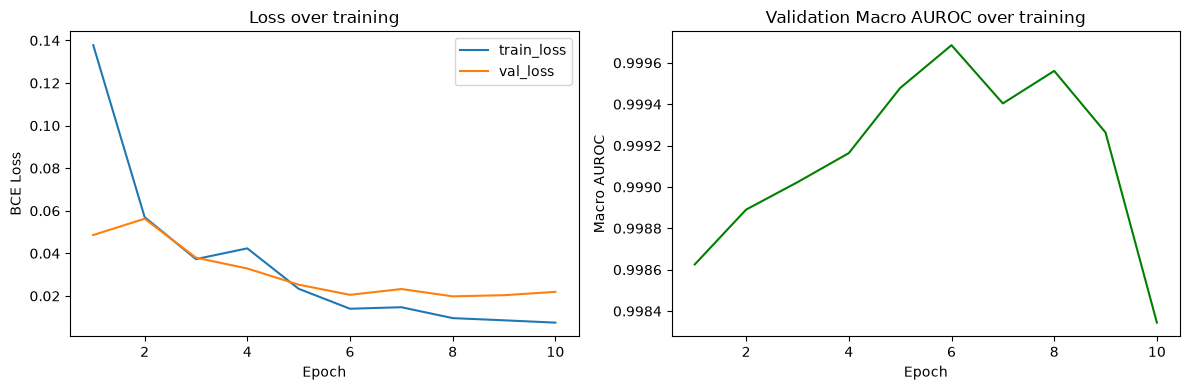

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(metrics_df["epoch"], metrics_df["train_loss"], label="train_loss")
axes[0].plot(metrics_df["epoch"], metrics_df["val_loss"], label="val_loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("BCE Loss")
axes[0].set_title("Loss over training")
axes[0].legend()

axes[1].plot(metrics_df["epoch"], metrics_df["val_macro_auroc"], color="green")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Macro AUROC")
axes[1].set_title("Validation Macro AUROC over training")

plt.tight_layout()
plt.savefig("../docs/training_curves.png", dpi=150)
plt.show()

## Per-class AUROC on the test set

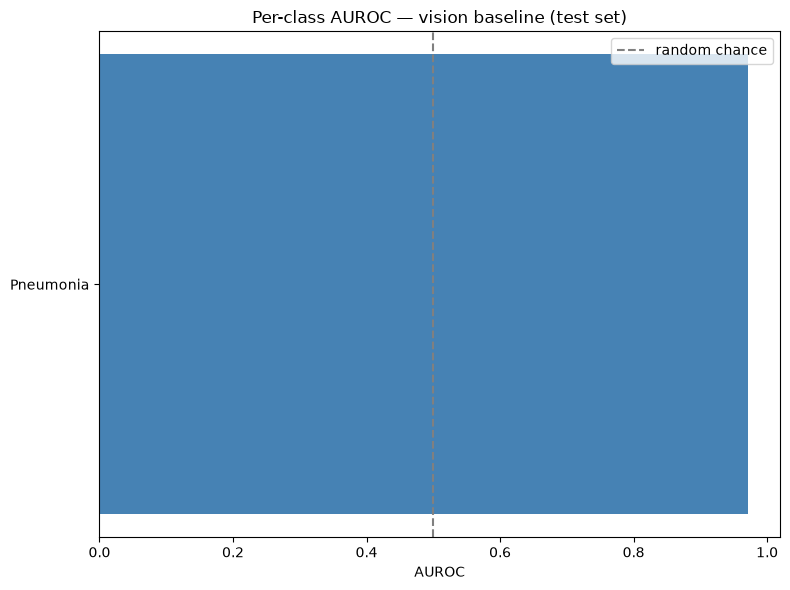

In [3]:
results_df = pd.read_csv(results_path)

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(results_df["class"], results_df["auroc"], color="steelblue")
ax.axvline(0.5, color="gray", linestyle="--", label="random chance")
ax.set_xlabel("AUROC")
ax.set_title("Per-class AUROC — vision baseline (test set)")
ax.legend()
plt.tight_layout()
plt.savefig("../docs/per_class_auroc.png", dpi=150)
plt.show()

## Notes

- Fill in qualitative observations here once you have real results: which
  classes the baseline struggles with (usually rare findings like Hernia),
  and how this compares once tabular fusion is added in the next phase.
- `docs/training_curves.png` and `docs/per_class_auroc.png` are also good
  images to drop directly into the README's Results section.